In [2]:
!pip install ultralytics pillow -q

In [3]:
import os, cv2, json, shutil, random
import numpy as np
from pathlib import Path
from PIL import Image, ImageFilter
import matplotlib.pyplot as plt
from ultralytics import YOLO

DATASET_PATH = "/kaggle/input/datasets/dgvdeelaka/handwritten-datatset/dataset"
WORK_DIR     = "/kaggle/working"
YOLO_DIR     = f"{WORK_DIR}/yolo_sentence_dataset"

# Get all classes
classes = sorted([
    d for d in os.listdir(DATASET_PATH)
    if os.path.isdir(os.path.join(DATASET_PATH, d))
])

print(f"Total character classes : {len(classes)}")
print(f"First 10 classes        : {classes[:10]}")

# Count images per class
counts = {}
for c in classes:
    counts[c] = len([
        f for f in os.listdir(os.path.join(DATASET_PATH, c))
        if f.lower().endswith(('.png','.jpg','.jpeg','.bmp'))
    ])

total = sum(counts.values())
min_c = min(counts.values())
max_c = max(counts.values())
print(f"Total images            : {total}")
print(f"Min images per class    : {min_c}")
print(f"Max images per class    : {max_c}")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Total character classes : 410
First 10 classes        : ['අ', 'ආ', 'ඇ', 'ඈ', 'ඉ', 'ඊ', 'උ', 'එ', 'ඒ', 'ඔ']
Total images            : 78730
Min images per class    : 185
Max images per class    : 199


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 3461 (\N{SINHALA LETTER AYANNA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Matplotlib currently does not support Sinhala natively.
  fig.canvas.print_figure(bytes_io, **kw)


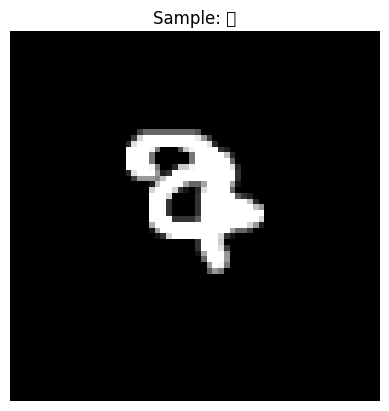

Character loader working correctly


In [4]:
IMAGE_EXTS = {'.png', '.jpg', '.jpeg', '.bmp'}

def load_char_image(fpath, size=64):
    """
    Load a character image, clean it, return white-background
    PIL image of given size.
    """
    img = cv2.imread(fpath, cv2.IMREAD_GRAYSCALE)
    if img is None:
        try:
            img = np.array(Image.open(fpath).convert('L'))
        except Exception:
            return None

    # denoise
    img = cv2.GaussianBlur(img, (3, 3), 0)

    # binarize
    _, img = cv2.threshold(
        img, 0, 255,
        cv2.THRESH_BINARY + cv2.THRESH_OTSU
    )

    # find tight crop around character pixels
    inv = cv2.bitwise_not(img)
    coords = cv2.findNonZero(inv)
    if coords is not None:
        x, y, w, h = cv2.boundingRect(coords)
        pad = 4
        x1 = max(0, x - pad)
        y1 = max(0, y - pad)
        x2 = min(img.shape[1], x + w + pad)
        y2 = min(img.shape[0], y + h + pad)
        img = img[y1:y2, x1:x2]

    # resize to square keeping aspect ratio
    h, w = img.shape
    max_dim = max(h, w)
    canvas = np.ones((max_dim, max_dim), dtype=np.uint8) * 255
    y_off = (max_dim - h) // 2
    x_off = (max_dim - w) // 2
    canvas[y_off:y_off+h, x_off:x_off+w] = img
    canvas = cv2.resize(canvas, (size, size), interpolation=cv2.INTER_AREA)

    return Image.fromarray(canvas)


# Test it on one image
sample_cls = classes[0]
sample_file = os.listdir(os.path.join(DATASET_PATH, sample_cls))[0]
sample_path = os.path.join(DATASET_PATH, sample_cls, sample_file)
test_img = load_char_image(sample_path)
if test_img:
    plt.imshow(test_img, cmap='gray')
    plt.title(f"Sample: {sample_cls}")
    plt.axis('off')
    plt.show()
    print("Character loader working correctly")
else:
    print("ERROR: could not load sample image — check dataset path")

In [5]:
# Build dict: class_name -> list of image file paths
image_pool = {}

for cls in classes:
    cls_path = os.path.join(DATASET_PATH, cls)
    files = [
        os.path.join(cls_path, f)
        for f in os.listdir(cls_path)
        if os.path.splitext(f)[1].lower() in IMAGE_EXTS
    ]
    if files:
        image_pool[cls] = files

print(f"Classes with images: {len(image_pool)}")
print(f"Ready to synthesize sentences")

Classes with images: 410
Ready to synthesize sentences


In [6]:
CHAR_SIZE    = 56     # each character rendered at this size
MIN_CHARS    = 4      # min characters per sentence
MAX_CHARS    = 10     # max characters per sentence
GAP_MIN      = 6      # min pixel gap between characters
GAP_MAX      = 18     # max pixel gap between characters
WORD_GAP_MIN = 24     # min gap for word space
WORD_GAP_MAX = 45     # max gap for word space
WORD_PROB    = 0.25   # probability of inserting a word space
LINE_PAD     = 20     # top/bottom padding in sentence image
SIDE_PAD     = 20     # left/right padding

NUM_TRAIN    = 6000   # training sentence images to generate
NUM_VAL      = 1000   # validation sentence images

random.seed(42)
np.random.seed(42)

# Create output directories
for split in ['train', 'val']:
    os.makedirs(f"{YOLO_DIR}/images/{split}", exist_ok=True)
    os.makedirs(f"{YOLO_DIR}/labels/{split}", exist_ok=True)


def make_sentence_image(idx, split):
    """
    Compose one sentence image from random characters.
    Returns (PIL image, list of YOLO annotation strings)
    """
    n_chars = random.randint(MIN_CHARS, MAX_CHARS)
    chosen_classes = random.choices(list(image_pool.keys()), k=n_chars)

    char_imgs = []
    for cls in chosen_classes:
        fpath = random.choice(image_pool[cls])
        img   = load_char_image(fpath, size=CHAR_SIZE)
        if img is None:
            img = Image.new('L', (CHAR_SIZE, CHAR_SIZE), 255)
        # slight random size variation for realism
        scale = random.uniform(0.85, 1.15)
        new_size = int(CHAR_SIZE * scale)
        new_size = max(32, min(80, new_size))
        img = img.resize((new_size, new_size), Image.LANCZOS)
        char_imgs.append(img)

    # compute canvas size
    total_h   = CHAR_SIZE + LINE_PAD * 2
    gaps      = []
    total_w   = SIDE_PAD * 2

    for i, cimg in enumerate(char_imgs):
        total_w += cimg.width
        if i < len(char_imgs) - 1:
            if random.random() < WORD_PROB:
                gap = random.randint(WORD_GAP_MIN, WORD_GAP_MAX)
            else:
                gap = random.randint(GAP_MIN, GAP_MAX)
            gaps.append(gap)
            total_w += gap

    # slight background noise for realism
    canvas_arr = np.random.randint(240, 256,
                                   (total_h, total_w),
                                   dtype=np.uint8)
    canvas = Image.fromarray(canvas_arr, mode='L')

    annotations = []
    x_cursor = SIDE_PAD

    for i, cimg in enumerate(char_imgs):
        cw, ch = cimg.size
        y_off = LINE_PAD + random.randint(-3, 3)  # slight vertical jitter
        y_off = max(0, min(total_h - ch, y_off))

        canvas.paste(cimg, (x_cursor, y_off))

        # YOLO bbox (class=0, normalised cx cy w h)
        cx = (x_cursor + cw / 2) / total_w
        cy = (y_off   + ch / 2) / total_h
        nw = cw / total_w
        nh = ch / total_h

        annotations.append(f"0 {cx:.6f} {cy:.6f} {nw:.6f} {nh:.6f}")
        x_cursor += cw
        if i < len(gaps):
            x_cursor += gaps[i]

    return canvas, annotations


# Generate all images
print(f"Generating {NUM_TRAIN} train + {NUM_VAL} val sentence images...")
print("This will take a few minutes...")

for i in range(NUM_TRAIN):
    img, ann = make_sentence_image(i, 'train')
    img_path = f"{YOLO_DIR}/images/train/{i:06d}.png"
    lbl_path = f"{YOLO_DIR}/labels/train/{i:06d}.txt"
    img.save(img_path)
    with open(lbl_path, 'w') as f:
        f.write('\n'.join(ann))
    if (i + 1) % 1000 == 0:
        print(f"  Train: {i+1}/{NUM_TRAIN}")

for i in range(NUM_VAL):
    img, ann = make_sentence_image(i, 'val')
    img_path = f"{YOLO_DIR}/images/val/{i:06d}.png"
    lbl_path = f"{YOLO_DIR}/labels/val/{i:06d}.txt"
    img.save(img_path)
    with open(lbl_path, 'w') as f:
        f.write('\n'.join(ann))
    if (i + 1) % 200 == 0:
        print(f"  Val:   {i+1}/{NUM_VAL}")

print("\nDone generating sentence images!")

Generating 6000 train + 1000 val sentence images...
This will take a few minutes...


/tmp/ipykernel_55/1049219472.py:64: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  canvas = Image.fromarray(canvas_arr, mode='L')


  Train: 1000/6000
  Train: 2000/6000
  Train: 3000/6000
  Train: 4000/6000
  Train: 5000/6000
  Train: 6000/6000
  Val:   200/1000
  Val:   400/1000
  Val:   600/1000
  Val:   800/1000
  Val:   1000/1000

Done generating sentence images!


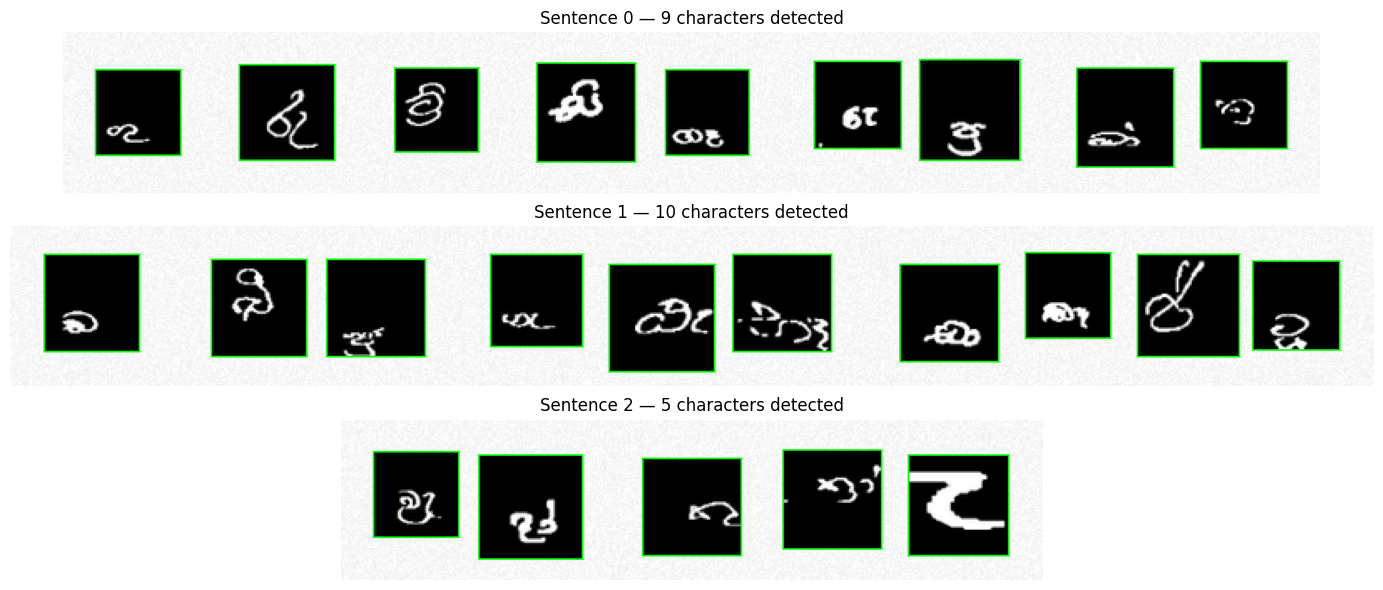

Green boxes = character bounding boxes YOLO will learn


In [7]:
fig, axes = plt.subplots(3, 1, figsize=(14, 6))

for ax_idx in range(3):
    fname = f"{ax_idx:06d}.png"
    img   = cv2.imread(f"{YOLO_DIR}/images/train/{fname}")
    lbl   = f"{YOLO_DIR}/labels/train/{ax_idx:06d}.txt"

    # draw bounding boxes
    with open(lbl) as f:
        lines = f.readlines()

    h, w = img.shape[:2]
    for line in lines:
        parts = line.strip().split()
        cx, cy, nw, nh = float(parts[1]), float(parts[2]), float(parts[3]), float(parts[4])
        x1 = int((cx - nw/2) * w)
        y1 = int((cy - nh/2) * h)
        x2 = int((cx + nw/2) * w)
        y2 = int((cy + nh/2) * h)
        cv2.rectangle(img, (x1,y1), (x2,y2), (0,255,0), 1)

    axes[ax_idx].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    axes[ax_idx].set_title(f"Sentence {ax_idx} — {len(lines)} characters detected")
    axes[ax_idx].axis('off')

plt.tight_layout()
plt.savefig('preview_sentences.png', dpi=120)
plt.show()
print("Green boxes = character bounding boxes YOLO will learn")

In [8]:
yaml_content = f"""path: {YOLO_DIR}
train: images/train
val:   images/val

nc: 1
names: ['character']
"""

yaml_path = f"{YOLO_DIR}/dataset.yaml"
with open(yaml_path, 'w') as f:
    f.write(yaml_content)

print("dataset.yaml written:")
print(yaml_content)

dataset.yaml written:
path: /kaggle/working/yolo_sentence_dataset
train: images/train
val:   images/val

nc: 1
names: ['character']



In [9]:
model = YOLO('yolov8s.pt')   # 's' (small) is better than 'n' for accuracy

results = model.train(
    data=yaml_path,
    epochs=100,
    imgsz=640,
    batch=32,
    device=0,             # GPU
    patience=20,
    name='sinhala_detector',
    project=f'{WORK_DIR}/runs',
    exist_ok=True,

    # critical: disable flips — they break Sinhala characters
    flipud=0.0,
    fliplr=0.0,

    # keep these augmentations — they help with real handwriting
    degrees=8.0,
    translate=0.08,
    scale=0.25,
    shear=4.0,
    mosaic=0.6,
    mixup=0.1,

    # optimizer
    optimizer='AdamW',
    lr0=0.001,
    lrf=0.01,
    warmup_epochs=3,

    verbose=True,
    save=True,
)

map50 = results.results_dict.get('metrics/mAP50(B)', 0)
print(f"\nBest mAP50 : {map50:.4f}")
print("Target     : above 0.85 for good segmentation")

Ultralytics 8.4.39 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/yolo_sentence_dataset/dataset.yaml, degrees=8.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.0, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.1, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=0.6, multi_scale=0.0, name=sinhala_detector, nbs=64, nms=False, opset=None, optimize=False, optimizer=AdamW, o

In [10]:
best_pt = f"{WORK_DIR}/runs/sinhala_detector/weights/best.pt"
val_model = YOLO(best_pt)
metrics   = val_model.val(data=yaml_path, device=0, verbose=False)

print(f"mAP50      : {metrics.box.map50:.4f}")
print(f"mAP50-95   : {metrics.box.map:.4f}")
print(f"Precision  : {metrics.box.mp:.4f}")
print(f"Recall     : {metrics.box.mr:.4f}")

if metrics.box.map50 >= 0.85:
    print("\nExcellent — ready to use in backend")
elif metrics.box.map50 >= 0.70:
    print("\nGood — will work, run more epochs for better results")
else:
    print("\nNeeds improvement — increase NUM_TRAIN to 10000 and retrain")

Ultralytics 8.4.39 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 11,125,971 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 786.0±203.7 MB/s, size: 24.0 KB)
val: Scanning /kaggle/working/yolo_sentence_dataset/labels/val.cache... 1000 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1000/1000 381.3Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 63/63 9.5it/s 6.6s<0.1s
                   all       1000       6950          1          1      0.995      0.995
Speed: 0.2ms preprocess, 2.7ms inference, 0.0ms loss, 1.2ms postprocess per image
Results saved to /kaggle/working/runs/detect/val
mAP50      : 0.9950
mAP50-95   : 0.9950
Precision  : 1.0000
Recall     : 1.0000

Excellent — ready to use in backend


Characters detected: 5


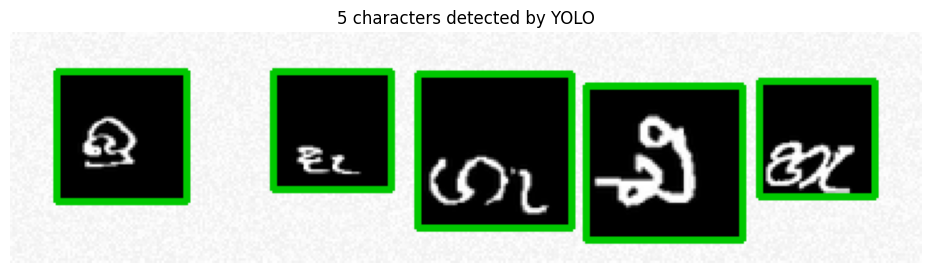

In [11]:
# Run inference on one generated image to visually confirm
test_img_path = f"{YOLO_DIR}/images/val/000000.png"
det_results   = val_model(test_img_path, conf=0.35, verbose=False)

img = cv2.imread(test_img_path)
boxes = det_results[0].boxes.xyxy.cpu().numpy()

print(f"Characters detected: {len(boxes)}")

for x1,y1,x2,y2 in boxes.astype(int):
    cv2.rectangle(img, (x1,y1), (x2,y2), (0,200,0), 2)

plt.figure(figsize=(14, 3))
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title(f"{len(boxes)} characters detected by YOLO")
plt.axis('off')
plt.show()

In [12]:
dest = f"{WORK_DIR}/sinhala_yolo.pt"
shutil.copy2(best_pt, dest)
print(f"Saved: {dest}")

from IPython.display import FileLink, display
display(FileLink('sinhala_yolo.pt'))

Saved: /kaggle/working/sinhala_yolo.pt


/kaggle/working/sinhala_yolo.pt